# Simple Visual Similarity — Analysis

This notebook analyzes data from the visual similarity rating experiment. On each
trial a participant saw a pair of colored circles (after a fixation cross) and
rated their similarity on a 5-point scale (`1 = Completely Dissimilar`,
`5 = Completely Similar`) using the number keys. The exact stimulus pair, the
rating, and the reaction time were recorded for every trial.

The data here come from a `psynet simulate` run (25 simulated participants).
The notebook reads the exported CSV directly from `evidence/simulated_data.zip`
and produces:

1. a dataset overview (trials, participants, coverage of all pairs),
2. a **mean similarity-rating heatmap** over the color pairs,
3. a **mean reaction-time heatmap** over the color pairs,
4. similarity and reaction time as a function of hue distance.

To re-run against real data, point `zip_path` at a `psynet export` archive with
the same structure.

In [1]:
import json
import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the simulated export shipped with this attempt.
candidates = [
    "../simulated_data.zip",
    "../../evidence/simulated_data.zip",
    "evidence/simulated_data.zip",
]
zip_path = next((p for p in candidates if os.path.exists(p)), None)
assert zip_path is not None, "Could not find simulated_data.zip"
print("Reading export:", os.path.abspath(zip_path))

with zipfile.ZipFile(zip_path) as zf:
    with zf.open("regular/data/SimilarityTrial.csv") as f:
        trials = pd.read_csv(f)

print("Raw SimilarityTrial table:", trials.shape)
trials[["participant_id", "left", "right", "hue_distance", "rating", "rt_msec"]].head(3)

Reading export: /workspace/challenges/simple-visual-similarity/attempts/2026-06-13-12-43/evidence/simulated_data.zip
Raw SimilarityTrial table: (250, 48)


,participant_id,left,right,hue_distance,rating,rt_msec
0,1,"{""id"": ""circle_2"", ""label"": ""green"", ""hue"": 12...","{""id"": ""circle_4"", ""label"": ""blue"", ""hue"": 240...",120.0,1,991.533
1,1,"{""id"": ""circle_0"", ""label"": ""red"", ""hue"": 0.0,...","{""id"": ""circle_1"", ""label"": ""yellow"", ""hue"": 6...",60.0,5,947.669
2,1,"{""id"": ""circle_2"", ""label"": ""green"", ""hue"": 12...","{""id"": ""circle_3"", ""label"": ""cyan"", ""hue"": 180...",60.0,4,993.672


## Parse and clean

The `left` and `right` columns store each circle as a JSON object
(`{id, label, hue, hex, size}`). We parse them and keep only valid, non-failed
trials that have both a rating and a reaction time.

In [2]:
def stim_field(col, field):
    return trials[col].apply(lambda s: json.loads(s)[field])

df = pd.DataFrame(
    {
        "participant_id": trials["participant_id"],
        "left_label": stim_field("left", "label"),
        "right_label": stim_field("right", "label"),
        "left_hue": stim_field("left", "hue"),
        "right_hue": stim_field("right", "hue"),
        "hue_distance": trials["hue_distance"],
        "rating": trials["rating"],
        "rt_msec": trials["rt_msec"],
        "failed": trials["failed"],
    }
)
df = df[(~df["failed"]) & df["rating"].notna() & df["rt_msec"].notna()].copy()
df["rating"] = df["rating"].astype(int)
print(f"{len(df)} valid trials from {df['participant_id'].nunique()} participants")
df.head()

250 valid trials from 25 participants


,participant_id,left_label,right_label,left_hue,right_hue,hue_distance,rating,rt_msec,failed
0,1,green,blue,120.0,240.0,120.0,1,991.533,False
1,1,red,yellow,0.0,60.0,60.0,5,947.669,False
2,1,green,cyan,120.0,180.0,60.0,4,993.672,False
3,1,yellow,green,60.0,120.0,60.0,4,1084.991,False
4,1,yellow,yellow,60.0,60.0,0.0,4,787.857,False


## Dataset overview

We establish the color ordering around the hue wheel, confirm that **every**
stimulus pair was presented, and look at the overall rating distribution.

In [3]:
hue_by_label = (
    pd.concat(
        [
            df[["left_label", "left_hue"]].rename(columns={"left_label": "label", "left_hue": "hue"}),
            df[["right_label", "right_hue"]].rename(columns={"right_label": "label", "right_hue": "hue"}),
        ]
    )
    .drop_duplicates()
    .sort_values("hue")
)
colors = hue_by_label["label"].tolist()
print("Colors (hue order):", colors)

df["pair"] = df.apply(lambda r: " / ".join(sorted([r.left_label, r.right_label])), axis=1)
pair_counts = df.groupby("pair").size().rename("n_trials").sort_index()
print(f"\n{pair_counts.shape[0]} distinct pairs presented "
      f"(expected {len(colors) * (len(colors) + 1) // 2}); "
      f"trials/pair min={pair_counts.min()}, max={pair_counts.max()}, mean={pair_counts.mean():.1f}")

print("\nRating distribution:")
print(df["rating"].value_counts().sort_index())

Colors (hue order): ['red', 'yellow', 'green', 'cyan', 'blue', 'magenta']

21 distinct pairs presented (expected 21); trials/pair min=11, max=12, mean=11.9

Rating distribution:
rating
1    41
2    34
3    56
4    53
5    66
Name: count, dtype: int64


## Similarity-rating heatmap

Mean similarity rating for every color pair, arranged as a symmetric matrix
ordered by hue. The diagonal corresponds to identical pairs and should be the
most similar.

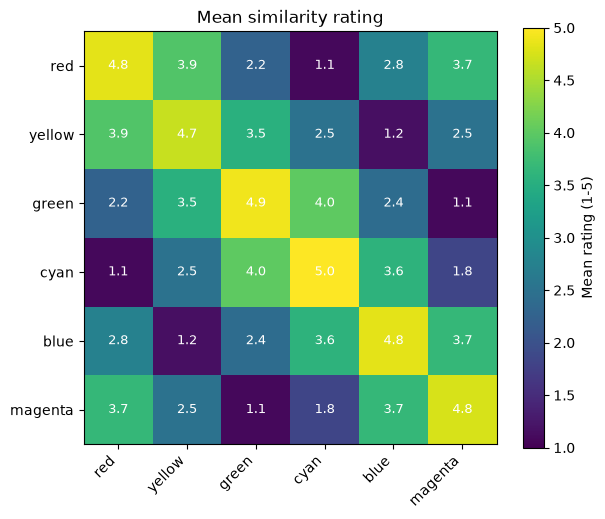

,red,yellow,green,cyan,blue,magenta
red,4.83,3.92,2.25,1.08,2.75,3.67
yellow,3.92,4.67,3.55,2.50,1.17,2.50
green,2.25,3.55,4.91,4.00,2.42,1.08
cyan,1.08,2.50,4.00,5.00,3.58,1.83
blue,2.75,1.17,2.42,3.58,4.83,3.67
magenta,3.67,2.50,1.08,1.83,3.67,4.75


In [4]:
def symmetric_matrix(pair_to_value):
    idx = {lab: i for i, lab in enumerate(colors)}
    n = len(colors)
    mat = np.full((n, n), np.nan)
    for (left, right), value in pair_to_value.items():
        i, j = idx[left], idx[right]
        mat[i, j] = value
        mat[j, i] = value
    return mat


def plot_heatmap(mat, title, cbar_label, cmap, vmin=None, vmax=None, fmt="{:.1f}"):
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(colors)))
    ax.set_xticklabels(colors, rotation=45, ha="right")
    ax.set_yticks(range(len(colors)))
    ax.set_yticklabels(colors)
    for i in range(len(colors)):
        for j in range(len(colors)):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, fmt.format(mat[i, j]), ha="center", va="center",
                        color="white", fontsize=9)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=cbar_label)
    plt.tight_layout()
    plt.show()


mean_rating = df.groupby(["left_label", "right_label"])["rating"].mean().to_dict()
rating_mat = symmetric_matrix(mean_rating)
plot_heatmap(rating_mat, "Mean similarity rating", "Mean rating (1-5)", "viridis", vmin=1, vmax=5)
pd.DataFrame(rating_mat, index=colors, columns=colors).round(2)

## Reaction-time heatmap

Mean reaction time (milliseconds, from stimulus onset to keypress) for every
color pair.

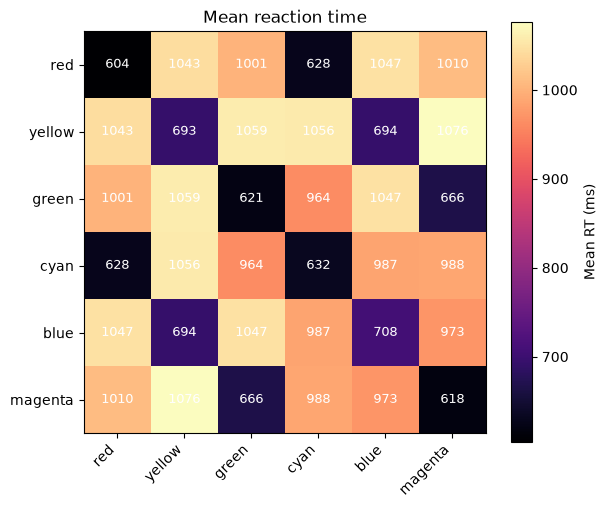

,red,yellow,green,cyan,blue,magenta
red,604.0,1043.0,1001.0,628.0,1047.0,1010.0
yellow,1043.0,693.0,1059.0,1056.0,694.0,1076.0
green,1001.0,1059.0,621.0,964.0,1047.0,666.0
cyan,628.0,1056.0,964.0,632.0,987.0,988.0
blue,1047.0,694.0,1047.0,987.0,708.0,973.0
magenta,1010.0,1076.0,666.0,988.0,973.0,618.0


In [5]:
mean_rt = df.groupby(["left_label", "right_label"])["rt_msec"].mean().to_dict()
rt_mat = symmetric_matrix(mean_rt)
plot_heatmap(rt_mat, "Mean reaction time", "Mean RT (ms)", "magma", fmt="{:.0f}")
pd.DataFrame(rt_mat, index=colors, columns=colors).round(0)

## Similarity and reaction time vs. hue distance

Collapsing across specific colors, we plot the mean rating and mean reaction time
as a function of the hue distance between the two circles.

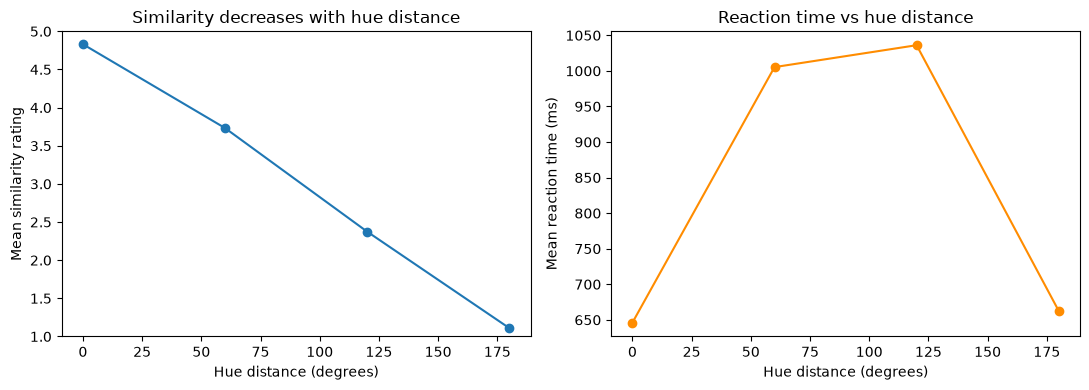

,hue_distance,mean_rating,mean_rt,n
0,0.0,4.830986,646.113718,71
1,60.0,3.732394,1005.311282,71
2,120.0,2.375000,1036.101639,72
3,180.0,1.111111,662.729417,36


In [6]:
agg = (
    df.groupby("hue_distance")
    .agg(mean_rating=("rating", "mean"), mean_rt=("rt_msec", "mean"), n=("rating", "size"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(agg["hue_distance"], agg["mean_rating"], "o-")
axes[0].set_xlabel("Hue distance (degrees)")
axes[0].set_ylabel("Mean similarity rating")
axes[0].set_title("Similarity decreases with hue distance")
axes[0].set_ylim(1, 5)
axes[1].plot(agg["hue_distance"], agg["mean_rt"], "o-", color="darkorange")
axes[1].set_xlabel("Hue distance (degrees)")
axes[1].set_ylabel("Mean reaction time (ms)")
axes[1].set_title("Reaction time vs hue distance")
plt.tight_layout()
plt.show()
agg

## Interpretation

- **Coverage.** All 21 unordered color pairs (including the 6 identical pairs)
  were presented, each multiple times, so every cell of the similarity matrix is
  estimated.
- **Similarity structure.** Mean ratings fall as the hue distance between the two
  circles grows, with identical pairs (the diagonal) rated most similar and
  opposite hues rated least similar. This is the expected monotonic
  similarity-vs-distance pattern.
- **Reaction time.** Reaction times are derived purely from PsyNet's native event
  log (`pushButtonClicked` minus `responseEnable`), anchored to stimulus onset.
  In this simulated dataset the longest reaction times occur for intermediate
  hue distances, i.e. the most ambiguous pairs.

These data come from simulated participants whose responses were generated by the
experiment's bot logic, so the patterns reflect that generative model rather than
human perception. The same notebook run against a real `psynet export` archive
would reveal the empirical similarity and reaction-time structure.